In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
os.makedirs("reports/figures/presentation", exist_ok=True)

In [3]:
df = pd.read_csv("../data/processed/tmdb_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (16718, 26)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,ROI,profitable
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",5.159580,1
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",4.252904,1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",5.430046,1
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",12.336312,1
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",6.903707,1


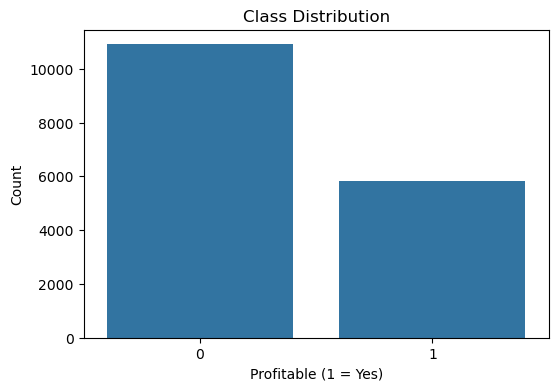

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="profitable", data=df)

plt.title("Class Distribution")
plt.xlabel("Profitable (1 = Yes)")
plt.ylabel("Count")

plt.savefig(
    "reports/figures/presentation/class_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

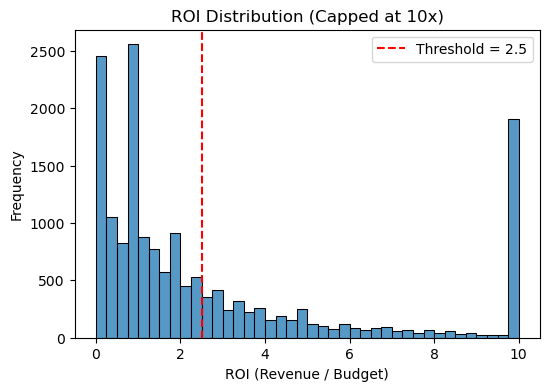

In [11]:
roi_capped = df["ROI"].clip(upper=10)

plt.figure(figsize=(6,4))

sns.histplot(roi_capped, bins=40)

plt.axvline(2.5, color="red", linestyle="--", label="Threshold = 2.5")

plt.title("ROI Distribution (Capped at 10x)")
plt.xlabel("ROI (Revenue / Budget)")
plt.ylabel("Frequency")
plt.legend()

plt.savefig(
    "reports/figures/presentation/roi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
pipeline = joblib.load("../artifacts/final_model.pkl")

model = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

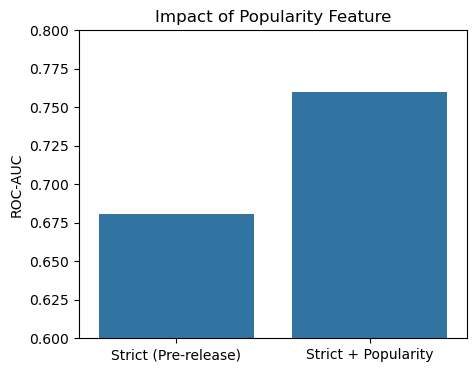

In [12]:
models = ["Strict (Pre-release)", "Strict + Popularity"]
auc_scores = [0.681, 0.760]

plt.figure(figsize=(5,4))
sns.barplot(x=models, y=auc_scores)

plt.ylim(0.6, 0.8)
plt.ylabel("ROC-AUC")
plt.title("Impact of Popularity Feature")

plt.savefig(
    "reports/figures/presentation/popularity_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

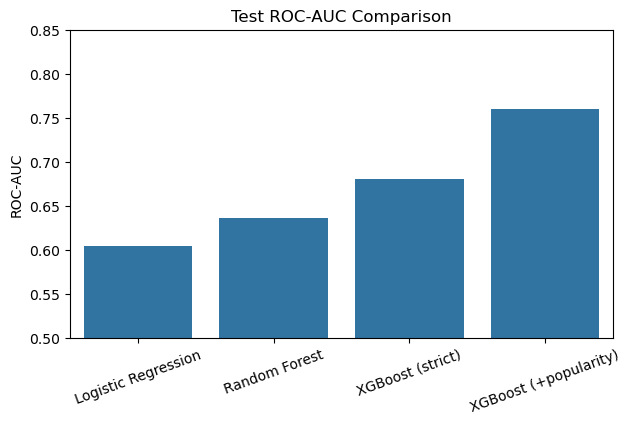

In [10]:
models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost (strict)",
    "XGBoost (+popularity)"
]

roc_auc_scores = [
    0.605,
    0.637,
    0.681,
    0.760  # replace if needed
]

plt.figure(figsize=(7,4))

sns.barplot(x=models, y=roc_auc_scores)

plt.ylim(0.5, 0.85)
plt.xticks(rotation=20)
plt.ylabel("ROC-AUC")
plt.title("Test ROC-AUC Comparison")

plt.savefig(
    "reports/figures/presentation/roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()